In [2]:
# Import some packages
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Uncomment the next line for use in a Jupyter notebook
%matplotlib inline

In [3]:
#read image whose name is 'example-grid1.jpg'
example_grid1_image = mpimg.imread('example-grid1.jpg')

#read image whose name is 'sample.jpg'
sample_image = mpimg.imread('sample.jpg')

#read image whose name is 'example_rock1.jpg'
example_rock1_image = mpimg.imread('example_rock1.jpg')

#read image whose name is 'mod_example-grid1.jpg'
image = mpimg.imread('mod_example-grid1.jpg')

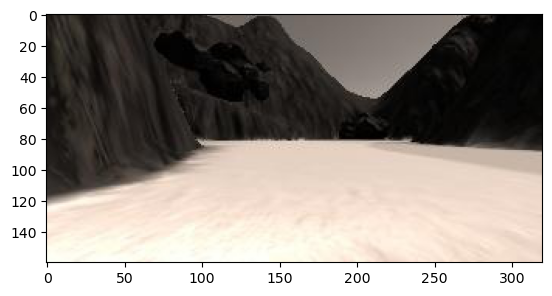

In [4]:
#plot the image
plt.imshow(sample_image)
plt.show()


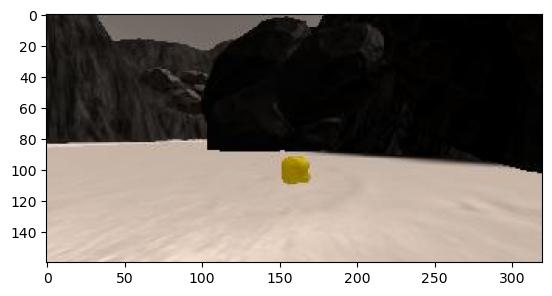

In [5]:
#plot the image
plt.imshow(example_rock1_image)
plt.show()


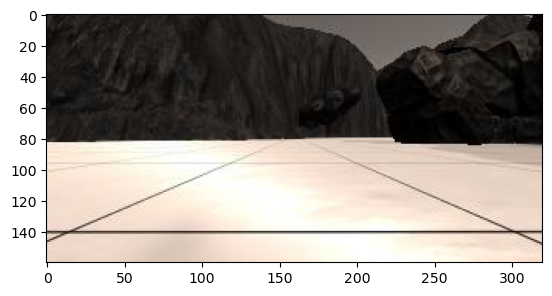

In [6]:
plt.imshow(example_grid1_image)
plt.show()

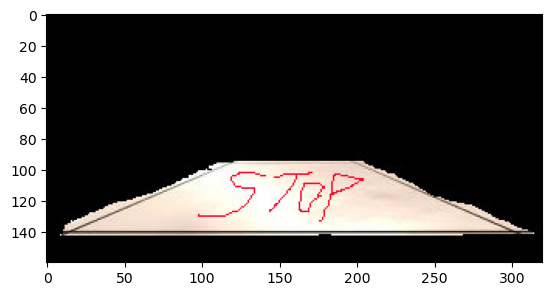

In [7]:
#plot the image
plt.imshow(image)
plt.show() 

In [8]:
print(sample_image.shape)
print(np.min(sample_image))
print(np.max(sample_image))

(160, 320, 3)
0
255


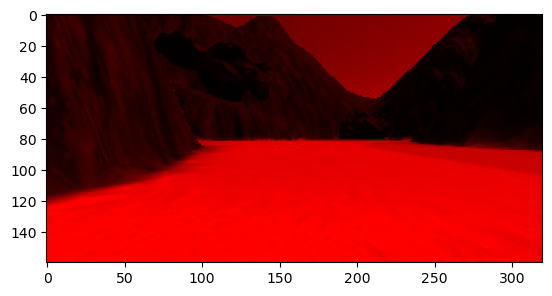

In [9]:
# enable red channel only of image
image1 = np.copy(sample_image)  # copy image to new variable called image1
image1[:,:,[1,2]] = 0    # enable red channel only

plt.imshow(image1)       # Plot image1
plt.show() 


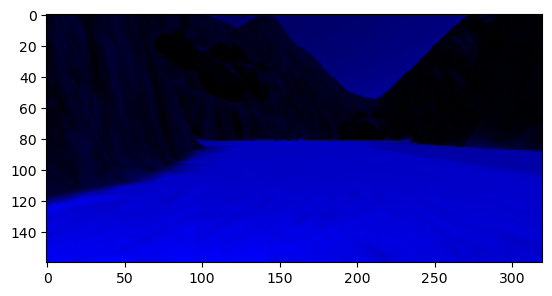

In [10]:
# enable blue channel only of image
image2 = np.copy(sample_image)  # copy image to new variable called image2
image2[:,:,[0,1]] = 0    # enable blue channel only

plt.imshow(image2)       # Plot image2
#plt.imshow(image2, cmap='gray')
plt.show()

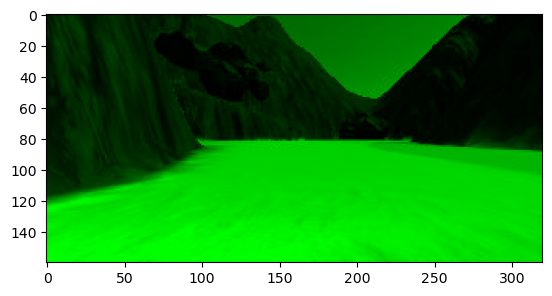

In [11]:
# enable green channel only of image
image3 = np.copy(sample_image)  # copy image to new variable called image3
image3[:,:,[0,2]] = 0    # enable green channel only

plt.imshow(image3)       # Plot image3
plt.show()


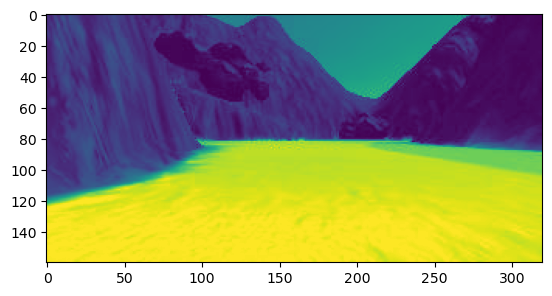

In [12]:
plt.imshow(sample_image[:,:,0])       # Plot image3
plt.show()


In [13]:
# this function returns image after do thresolding 
def navigable_thresh(img, rgb_thresh=(0, 0, 0)):
    # create single channel image called color_select
    # this image has same size of img but totally initialized to zero
    color_select = np.zeros_like(img[:,:,0])
    
    # preform logic operation AND for
    # boolean array result from   img[:,:,0] > rgb_thresh[0]
    # boolean array result from   img[:,:,0] > rgb_thresh[1]
    # boolean array result from   img[:,:,0] > rgb_thresh[2]
    # the result will be boolean array
    
    above_thresh = (img[:,:,0] > rgb_thresh[0]) & (img[:,:,1] > rgb_thresh[1]) & (img[:,:,2] > rgb_thresh[2])
    
    # Index the array of zeros with the boolean array and set to 1
    color_select[above_thresh] = 1
    
    return color_select



def obstacle_thresh(img, rgb_thresh=(160, 160, 160)):
    """Identify the image pixels that are above the provided threshold. Each
    threshold value can range between 0 and 255, with 160 doing a nice job
    of identifying ground pixels only.
    :param img: Numpy 3d array (x, y, RGB layers)
    :param rgb_threh: 3 item tuple of integers specifying the threshold for
        excluding pixel values
    :return: Numpy 2d array (x, y) of the binary image
    """
    # Create an array of zeros with the same xy size as img, but single channel
    color_select = np.zeros_like(img[:,:,0])
    # Require that each pixel be below all three threshold values in rbg_thresh.
    #   Values below the threshold will now contain a boolean array with TRUE.
    below_thresh = ((img[:,:,0] < rgb_thresh[0]) &
                    (img[:,:,1] < rgb_thresh[1]) &
                    (img[:,:,2] < rgb_thresh[2]))
    # Index the array of zeros with the boolean array and set to 1
    color_select[below_thresh] = 1
    return color_select



def rock_thresh(img):
    """Check the image for yellow rocks using OpenCV for determining the
    mask required.
    :param img: Numpy 3d array (x, y, RGB layers)
    :return: Numpy 2d array (x, y) of the binary image
    """
    # Convert BGR to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV, 3)
    
    # Define range of yellow colors in HSV
    lower_yellow = np.array([20, 150, 100], dtype='uint8')
    upper_yellow = np.array([50, 255, 255], dtype='uint8')
    
    # Threshold the HSV image to get only yellow colors
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    return mask 

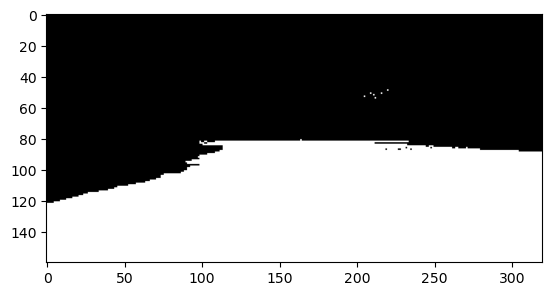

In [14]:
# preform thresolding on image and store image in variable called navigable
navigable = navigable_thresh(sample_image, (160,160,160))

# display navigable
plt.imshow(navigable, cmap='gray')
plt.show()

(160, 320)


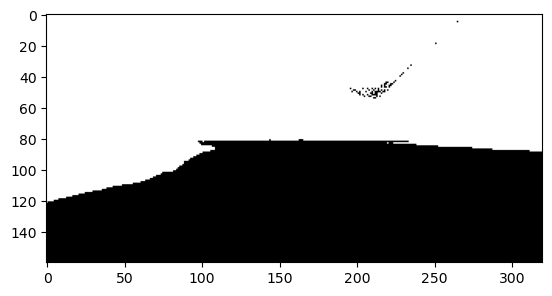

In [16]:
# preform thresolding on image and store image in variable called obstacles
obstacles = obstacle_thresh(sample_image, (160,160,160))
print(obstacles.shape)
# display colorsel
plt.imshow(obstacles, cmap='gray')
plt.show()

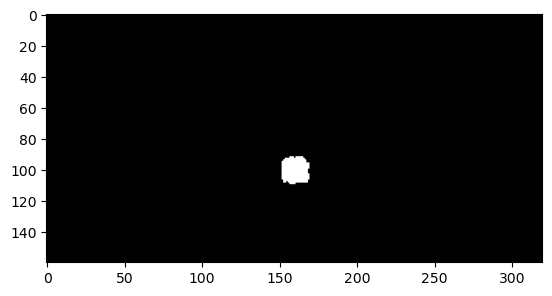

In [51]:
# preform thresolding on image and store image in variable called rock_samples
rock_samples = rock_thresh(example_rock1_image)

# display rock_samples
plt.imshow(rock_samples, cmap='gray')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


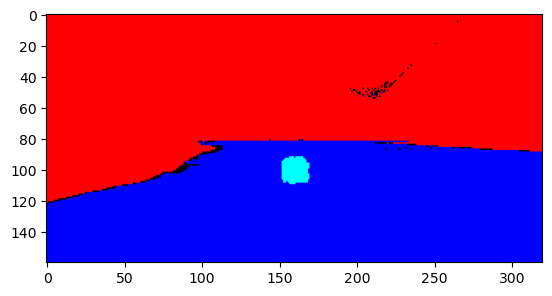

In [52]:
vision_image = np.zeros((160, 320, 3), dtype=np.float32) 
vision_image[:,:,0] = obstacles * 255
vision_image[:,:,1] = rock_samples * 255
vision_image[:,:,2] = navigable * 255

# display vision_image
plt.imshow(vision_image, cmap='gray')
plt.show()

In [53]:
# this function return image after perform perspect transformation   
def perspect_transform(img, src, dst):
    
    # Get transform matrix using cv2.getPerspectivTransform()
    M = cv2.getPerspectiveTransform(src, dst)
    
    # Warp image using cv2.warpPerspective()
    # keep same size as input image
    return cv2.warpPerspective(img, M, (img.shape[1], img.shape[0]))
    
    return warped

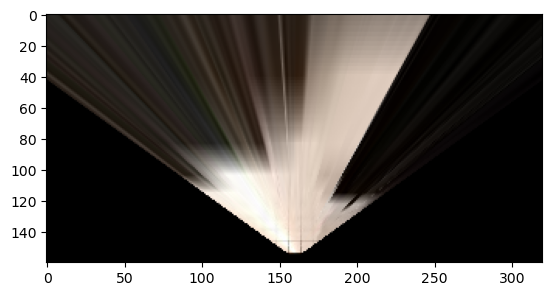

In [54]:
"""
  out images are 160v * 320h
  image.shape[0] = 160   (160 pixels vertically)
  image.shape[1] = 320   (320 pixels horizonally)
"""

# macros
dst_size = 4
bottom_offset = 6


# Define source and destination points (must be written in same path)
source = np.float32([[15 ,140 ], [301 , 140 ], [200 ,96 ], [118 ,96 ]])

destination = np.float32([
                 [160-dst_size, 160-bottom_offset], 
                 [160+dst_size, 160-bottom_offset], 
                 [160+dst_size, 160-2*dst_size - bottom_offset], 
                 [160-dst_size, 160-2*dst_size - bottom_offset]
                ])      


"""
destination = np.float32([
                 [0,160], 
                 [320,160], 
                 [320,0], 
                 [0,0]
                ])      
"""

# preform prespective transformation on image and store image in variable called warped
warped = perspect_transform(example_grid1_image, source, destination)


# display warped
plt.imshow(warped)
plt.show()

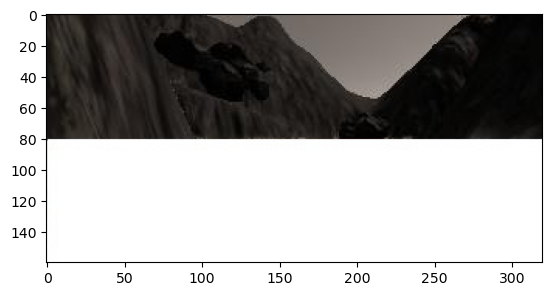

In [55]:
#read image whose name is 'example-grid1.jpg'
image = mpimg.imread('mod_sample.jpg')
plt.imshow(image)
plt.show() 

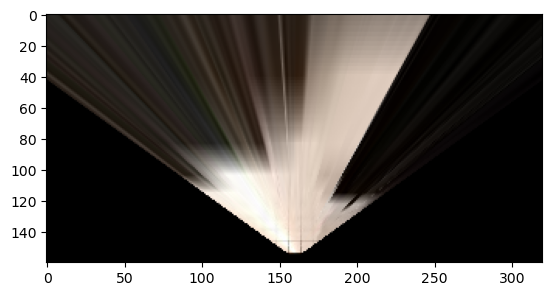

In [56]:
# preform prespective transformation on image and store image in variable called warped
warped = perspect_transform(example_grid1_image, source, destination)

# display warped
plt.imshow(warped)
plt.show()

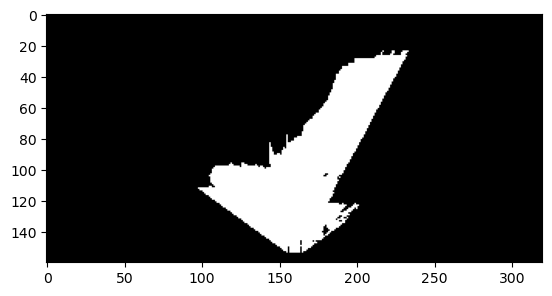

In [57]:
# preform prespective transformation on image and store image in variable called warped
warped = perspect_transform(example_grid1_image, source, destination)


# preform thresolding on wrapped and store image in variable called colorsel
navigable = navigable_thresh(img=warped, rgb_thresh=(160, 160, 160)) 
obstacles = obstacle_thresh(img=warped, rgb_thresh=(140, 140, 140))
rock_samples = rock_thresh(img=warped)


# display image after preforming prespective transformation and thresholding
plt.imshow(navigable, cmap='gray')
plt.show()

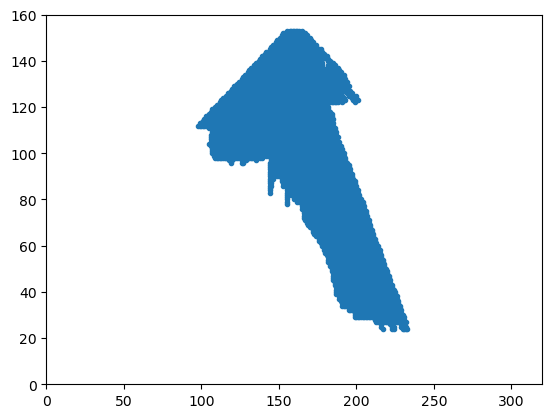

In [59]:
# define array to hold y positions of non zero pixels in  colorsel called ypos
# define array to hold x positions of non zero pixels in  colorsel calledxpos

# fill ypos array with y position of non zero pixels in  colorsel
# fill xpos array with x position of non zero pixels in  colorsel
ypos, xpos = navigable.nonzero()


# make range of x axis in figure 0 --> 320
plt.xlim(0, 320)


# make range of y-axis in figure 0 --> 160
plt.ylim(0, 160)


# plot non zero pixels in colorsel
plt.plot(xpos, ypos, '.')


plt.show()


# note we didnot 
# plt.imshow --> show image zero of y axis in bottom left
#            --> show image zero of x axis in top left

In [60]:
"""
  image.shape return array   
  first element of this array is height of pixels
  second element of this array is weight of pixels
  first element of this array is no of channel
"""
print(image.shape)

(160, 320, 3)


In [61]:
def rover_coords(binary_img):  
    # fill ypos array with y position of non zero pixels in  binary_img
    # fill xpos array with x position of non zero pixels in  binary_img
    ypos, xpos = binary_img.nonzero()
    
    
    # Calculate pixel positions with reference to the rover position being at the center bottom of the image.     
    # we know that binary_img.shape[0] = 160
    # we know that binary_img.shape[1] = 320
    x_pixel = -(ypos-160).astype(float)
    y_pixel = -(xpos-160).astype(float)                                                   
    
    return x_pixel, y_pixel

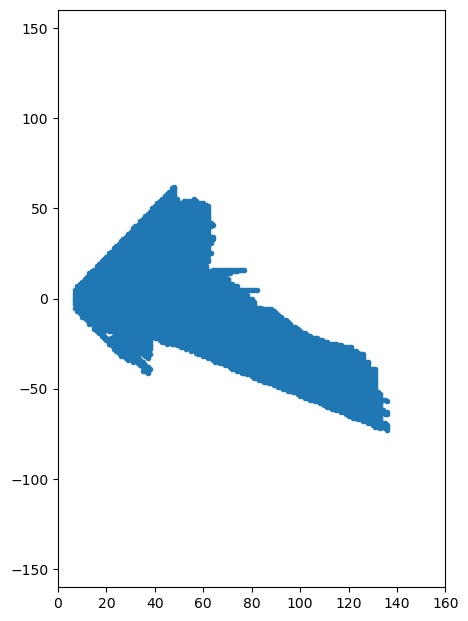

In [65]:
xpix, ypix = rover_coords(navigable)

fig = plt.figure(figsize=(5, 7.5))
plt.plot(xpix, ypix, '.')


# make range of y axis in figure -160 --> 160
plt.ylim(-160, 160)


# make range of x axis in figure 0 --> 160
plt.xlim(0, 160)


plt.show()

In [66]:
navigable_xpix, navigable_ypix = rover_coords(binary_img=navigable)
obstacles_xpix, obstacles_ypix = rover_coords(binary_img=obstacles)
rocks_xpix, rocks_ypix = rover_coords(binary_img=rock_samples)

In [68]:
############################# helper functions to be used in pix_to_world #####################################

# this function rotates group of pixels 
# whose y coordinates are in  ypix array and x coordinates are in xpix array
def rotate_pix(xpix, ypix, yaw):
    # Convert yaw to radians
    yaw_rad = yaw * np.pi / 180
    
    # from rotation matrix
    #
    #   [  xpix_rotated  ]       [   cos(rotational_angle)           -sin(rotational_angle) ] [ xpix ]
    #   [                ]   =   [                                                          ] [      ]
    #   [  ypix_rotated  ]       [   sin(rotational_angle)           cos(rotational_angle)  ] [ ypix ]
    
    xpix_rotated = (xpix * np.cos(yaw_rad)) - (ypix * np.sin(yaw_rad))                         
    ypix_rotated = (xpix * np.sin(yaw_rad)) + (ypix * np.cos(yaw_rad))
    
    # Return the result  
    return xpix_rotated, ypix_rotated




# this function takes pixels after rotatation by yaw angle and transfor axes to to point (xpos,ypos)
def translate_pix(xpix_rot, ypix_rot, xpos, ypos, scale): 
    # Apply a scaling and a translation
    xpix_translated = (xpix_rot / scale) + xpos
    ypix_translated = (ypix_rot / scale) + ypos
    
    # Return the result  
    return xpix_translated, ypix_translated


###############################################################################################################

# this function applies rotation by yaw angle , axes transfer and clipping
def pix_to_world(xpix, ypix, xpos, ypos, yaw, world_size, scale):
    # Apply rotation by yaw angle
    xpix_rot, ypix_rot = rotate_pix(xpix, ypix, yaw)
    
    # Apply axes transfer to point (xpos,ypos)
    xpix_tran, ypix_tran = translate_pix(xpix_rot, ypix_rot, xpos, ypos, scale)
    
    # Clip to world_size
    x_pix_world = np.clip(np.int_(xpix_tran), 0, world_size - 1)
    y_pix_world = np.clip(np.int_(ypix_tran), 0, world_size - 1)
    
    # Return the result
    return x_pix_world, y_pix_world

In [73]:
worldmap = np.zeros((200, 200, 3), dtype=np.float32)

scale = dst_size * 2 + 3
xpos, ypos = (100,100)
yaw = 200
worldmap_size = worldmap.shape[0]
    
navigable_x_world, navigable_y_world = pix_to_world(xpix=navigable_xpix, ypix=navigable_ypix,xpos=xpos, ypos=ypos, yaw=yaw, world_size=worldmap_size, scale=scale)
obstacles_x_world, obstacles_y_world = pix_to_world(xpix=obstacles_xpix, ypix=obstacles_ypix,xpos=xpos, ypos=ypos, yaw=yaw, world_size=worldmap_size, scale=scale)
rocks_x_world, rocks_y_world = pix_to_world(xpix=rocks_xpix, ypix=rocks_ypix,xpos=xpos, ypos=ypos, yaw=yaw, world_size=worldmap_size, scale=scale)

# 7) Update Rover worldmap (to be displayed on right side of screen)
#worldmap[obstacles_y_world, obstacles_x_world, 0] += 1
worldmap[rocks_y_world, rocks_x_world, 1] = 255
worldmap[navigable_y_world, navigable_x_world, 2] += 1

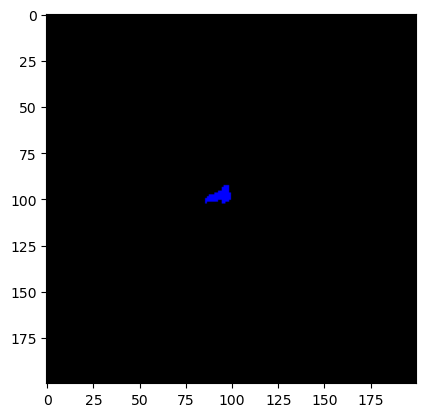

In [74]:
# display vision_image
plt.imshow(worldmap, cmap='gray')
plt.show()

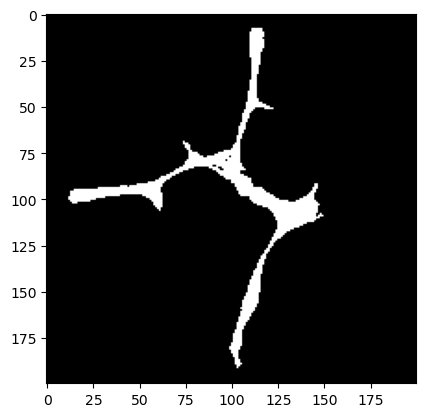

In [82]:
ground_truth = mpimg.imread('map_bw.png')

# display 
plt.imshow(ground_truth, cmap='gray')
plt.show()

# This next line creates arrays of zeros in the red and blue channels
# and puts the map into the green channel.  This is why the underlying 
# map output looks green in the display image
ground_truth_3d = np.dstack((ground_truth*0, ground_truth*255, ground_truth*0)).astype(np.float32)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


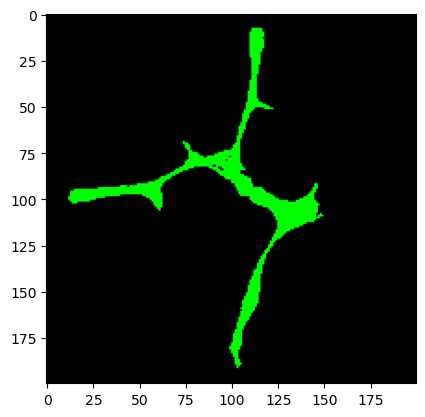

In [83]:
# display 
plt.imshow(ground_truth_3d, cmap='gray')
plt.show()